In [12]:
import igl
import numpy as np
import scipy.sparse as sp
from scipy.sparse.linalg import eigsh, splu
from scipy.sparse import diags
from src.fatemarkers import FateMarkers
from src import utils 
from meshplot import plot, subplot 
from matplotlib import pyplot as plt
import json 

import vtk 
import time 

In [2]:
import importlib

import src.meshharm 
import src.fatemarkers
importlib.reload(src.meshharm)
importlib.reload(src.fatemarkers)
from src.fatemarkers import FateMarkers

In [3]:
folder_path = 'Data/20260224/'

with open(f"{folder_path}config.json", 'r') as f:
        cfg = json.load(f)

annotation_names = cfg['annotation_names']
reverse_annotation_names = {v: k for k, v in annotation_names.items()}
round_name = cfg['rounds']['day4p5']
mesh_name = cfg['mesh_name']
zarr_name = cfg['zarr_names']['day4p5']

### Get random organoid indices

In [5]:
import pandas as pd 

df = pd.read_csv(f'Data/20251001/organoids_metadata.csv')
print(df.head())

# filter by percentile frac 

df_filtered = df[df['fraction_recon'] < np.percentile(df['fraction_recon'], 95)]

               id time  fraction_recon       area  complexity
0   day1p5_A01_96  1p5        0.000254  17.979122           2
1  day1p5_A01_140  1p5        0.000242  18.558704           2
2  day1p5_A01_154  1p5        0.000258  20.502855           2
3   day1p5_A01_41  1p5        0.000246  21.398077           2
4   day1p5_A01_68  1p5        0.000282  14.398316           2


In [6]:
ids = df_filtered['id'][df['complexity'] > 4].to_list() 
randomly_selected_ids = np.random.choice(ids, size=5, replace=False)
print(randomly_selected_ids)

['day3_A04_105' 'day4p5-more_C03_79' 'day4_B02_22' 'day4p5-more_C01_7'
 'day4_B01_4']


In [7]:
pairs = ['day4p5-more_C05_120', 'day4_B01_38']

### Load mesh and compute coefficients

In [26]:
i = 0
# label = pairs[i].split('_')
# print(label)

label = 'day4p5_B06_63'.split('_')
path = f'{folder_path}/fractal_output/{label[0]}/{zarr_name}/{label[1][0]}/{label[1][1:]}/{round_name}/meshes/{mesh_name}/{label[2]}.vtp'
m = FateMarkers()

print(path)

# loads all the results inc fate markers 
m.load_mesh_from_file(path) 
m.align_with_pca() 
m.precompute_eigens() 
# _ = m.compute_coefficients() 

Data/20260224//fractal_output/day4p5/r0.zarr/B/06/0_fused_zillum_registered/meshes/nnorg_linked_smooth_multi_annotated_class_projection/63.vtp


In [24]:
print(m.area) 

928.1135084747417


In [27]:
plot(m.v, m.f, c=m.modes[:, 3])

Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(1.2084202…

In [19]:
sec_cell_names = cfg['sec_cell_names']
secretory_cell_indices = [m.field_names.index(name) for name in sec_cell_names]

for idx in secretory_cell_indices:
    print(idx, reverse_annotation_names[m.field_names[idx]])
    plot(m.v, m.f, c=m.fields[:, idx])

6 lyz


Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(0.0138081…

0 muc


Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(0.0138081…

4 agr


...

Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(0.0138081…

2 gluc


Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(0.0138081…

8 chroma


Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(0.0138081…

In [8]:
lgr5_index = m.field_names.index(annotation_names['lgr'])
plot(m.v, m.f, c=m.fields[:, lgr5_index])

print(sec_cell_names) 
m._refine_lgr5_marker(sec_cell_names=sec_cell_names) 
plot(m.v, m.f, c=m.fields[:, lgr5_index])

Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(-0.520882…

['0.C03.percentile99_class', '0.C04.percentile99_class', '1.C02.percentile99_class', '1.C03.percentile99_class', '1.C04.percentile99_class']


Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(-0.520882…

In [9]:
# state an order 
correct_order = list(annotation_names.keys())
indices = [m.field_names.index(annotation_names[name]) for name in correct_order] 

### Testing mesh rescaling 

In [23]:
target_faces = 2562  # or use a ratio like f.shape[0] // 2

print(m.v.shape[0], m.f.shape[0])
_, v_dec, f_dec, j, i = igl.decimate(m.v, m.f, target_faces)

L = -igl.cotmatrix(v_dec, f_dec)
print('eigval of L:', sp.linalg.eigsh(L, k=6, which='SM')[0])
mass_matrix = igl.massmatrix(v_dec, f_dec, igl.MASSMATRIX_TYPE_VORONOI)
eigvals, eigvecs = sp.linalg.eigsh(L, k=(m.lmax**2), M=mass_matrix, sigma=0, which='LM')
print('eigvals of generalised equation:', eigvals[:10])
print('eigvecs:', eigvecs[0].min(), eigvecs[0].max())
print('mean mesh spacing:', np.mean(mass_matrix.diagonal()))
print('total area:', mass_matrix.diagonal().sum())

18001 35998
eigval of L: [5.23519469e-16 4.31953494e-03 1.12752632e-02 2.90641459e-02
 3.53049920e-02 5.24563400e-02]
eigvals of generalised equation: [2.63273984e-17 6.16683036e-03 1.58998377e-02 4.09690371e-02
 5.01357474e-02 7.36216214e-02 8.68005381e-02 1.00634159e-01
 1.17167248e-01 1.20263822e-01]
eigvecs: -0.08970312767095341 0.12204606514045965
mean mesh spacing: 0.7106642365988713
total area: 911.782215556352


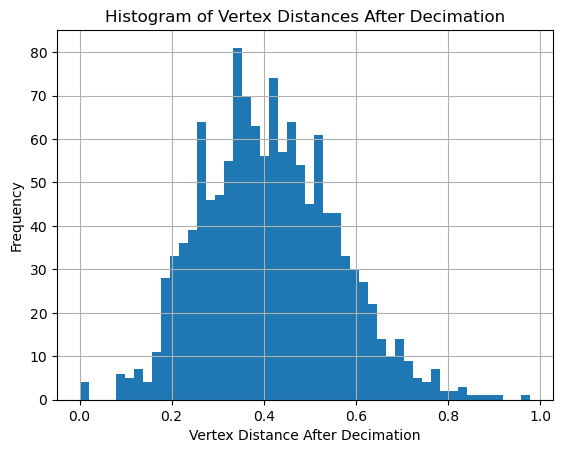

In [24]:
diff = np.linalg.norm(m.v[i] - v_dec, axis=-1) 

plt.hist(diff, bins=50)
plt.xlabel('Vertex Distance After Decimation')
plt.ylabel('Frequency')
plt.title('Histogram of Vertex Distances After Decimation')
plt.grid(True)
plt.show()

In [28]:
plot(v_dec, f_dec, c=diff)

Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(-0.518577…

In [46]:
def map_scalar_fields_to_new_mesh(V_old, F_old, V_new, S_old):
    V_old = V_old.astype(np.float64)
    if S_old.ndim == 1:
        S_old = S_old[:, np.newaxis]
    
    # 1. Find closest points
    _, I_face, C = igl.point_mesh_squared_distance(V_new, V_old, F_old)
    
    # 2. Get the vertices of the closest triangles
    v0 = V_old[F_old[I_face, 0]]
    v1 = V_old[F_old[I_face, 1]]
    v2 = V_old[F_old[I_face, 2]]
    
    # 3. Calculate Barycentric Coordinates
    B = igl.barycentric_coordinates_tri(C, v0, v1, v2)
    
    # 4. Interpolate (Vectorized version is much faster than a loop)
    # We use F_old[I_face, k] to get the VERTEX indices for the k-th corner of the face
    S_new = (S_old[F_old[I_face, 0]] * B[:, [0]] + 
             S_old[F_old[I_face, 1]] * B[:, [1]] + 
             S_old[F_old[I_face, 2]] * B[:, [2]]) 
             
    return S_new.squeeze()

map_scalar_fields_to_new_mesh(m.v, m.f, v_dec, m.fields)


array([[   0.        ,    0.        ,    0.        , ...,    0.        ,
           0.        ,    0.        ],
       [ 633.52600448,    0.        ,    0.        , ...,    0.        ,
           0.        ,    0.        ],
       [   0.        ,    0.        ,    0.        , ...,    0.        ,
           0.        ,    0.        ],
       ...,
       [ 670.        ,    0.        ,    0.        , ...,    0.        ,
           0.        , 1808.        ],
       [1110.        ,    0.        , 5476.        , ...,    0.        ,
           0.        ,    0.        ],
       [ 705.19257499,    0.        ,    0.        , ...,    0.        ,
           0.        , 1754.77754269]])

In [42]:
print(m.fields.shape)
hks = m.compute_hks_for_new_times(new_ts=[1, 4, 25, 10], coeffs=False)
print(hks.shape)

scalar_fields = np.hstack([hks, m.fields]) # (V_old, K) where K = num_hks + num_cell_fates

print(scalar_fields.shape)

(18001, 7)
(18001, 4)
(18001, 11)


In [216]:
print('----------------')
print('scaled mesh')

L = -igl.cotmatrix(m.v*10, m.f)
print('eigval of L:', sp.linalg.eigsh(L, k=6, which='SM')[0])
mass_matrix = igl.massmatrix(m.v*10, m.f, igl.MASSMATRIX_TYPE_VORONOI)
eigvals, eigvecs = sp.linalg.eigsh(L, k=(m.lmax**2), M=mass_matrix, sigma=0, which='LM')
hks = np.sum(np.exp(-eigvals[np.newaxis, :]*400) * eigvecs**2, axis=1)
print('hks:', hks.min(), hks.max(), hks.mean())
print('eigvals of generalised equation:', eigvals[:10])
print('eigvecs:', eigvecs[0].min(), eigvecs[0].max())
print('mean mesh spacing:', np.mean(mass_matrix.diagonal()))
area = mass_matrix.diagonal().sum()
print('total area:', area)

test_func = np.ones(m.v.shape[0])
coeff = eigvecs.T @ (mass_matrix @ test_func) 

print('coeff:', coeff[0]/np.sqrt(area))

print('----------------')
print('original mesh')
L = - igl.cotmatrix(m.v, m.f)
print('eigval of L:', sp.linalg.eigsh(L, k=6, which='SM')[0])

hks = np.sum(np.exp(-m.eigvals[np.newaxis, :]*4) * m.eigvecs**2, axis=1)
print('hks:', hks.min(), hks.max(), hks.mean())
print('eigvals:', m.eigvals[:10])
print('eigvecs:', m.eigvecs[0].min(), m.eigvecs[0].max())
print('mean mesh spacing:', np.mean(m.mass_matrix.diagonal()))
area = m.mass_matrix.diagonal().sum()
print('total area:', area)

coeff = m.eigvecs.T @ (m.mass_matrix @ test_func) 
print('coeff:', coeff[0]/np.sqrt(area))

----------------
scaled mesh
eigval of L: [-4.7585493e-07  8.1457838e-04  1.7159571e-03  1.8637427e-03
  3.0264664e-03  3.6603629e-03]
hks: 0.00018758008 0.00027241922 0.0002183982
eigvals of generalised equation: [3.4373940e-08 7.5574568e-04 1.3666200e-03 1.4563160e-03 2.5577808e-03
 3.3577748e-03 3.4396108e-03 4.3404819e-03 4.4155554e-03 5.3884597e-03]
eigvecs: -0.01775223 0.015921287
mean mesh spacing: 1.2013521
total area: 21624.338
coeff: 1.0000001638861573
----------------
original mesh
eigval of L: [6.0068459e-07 8.1390416e-04 1.7202066e-03 1.8643977e-03 3.0268866e-03
 3.6604784e-03]
hks: 0.018757926 0.027241956 0.02183975
eigvals: [4.0896825e-06 7.5574994e-02 1.3666277e-01 1.4563201e-01 2.5577801e-01
 3.3577853e-01 3.4396246e-01 4.3405002e-01 4.4155723e-01 5.3884667e-01]
eigvecs: -0.15921864 0.17752211
mean mesh spacing: 0.012013522
total area: 216.2434
coeff: 0.9999999670665729


In [69]:
i = -2 
j = 0 

fields = m.fields[:, indices] 
fm1 = fields[:, i] 
fm2 = fields[:, j]

print(np.mean((fm1 - np.mean(fm1)) * (fm2 - np.mean(fm2)))) 

coeffs_fm = m.coeffs_fm[:, indices]
fm1_coeffs = coeffs_fm[:, i]
fm2_coeffs = coeffs_fm[:, j]

print(np.sum(fm1_coeffs[1:] * fm2_coeffs[1:])/m.mass_matrix.diagonal().sum())

0.0
0.0


In [70]:
print(correct_order[i], correct_order[j])
plot(m.v, m.f, fm1) 
plot(m.v, m.f, fm2)

sero lgr


Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(0.1419911…

Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(0.1419911…

### Check reconstruction quality for a series of lmax values

maximumm l index: 15


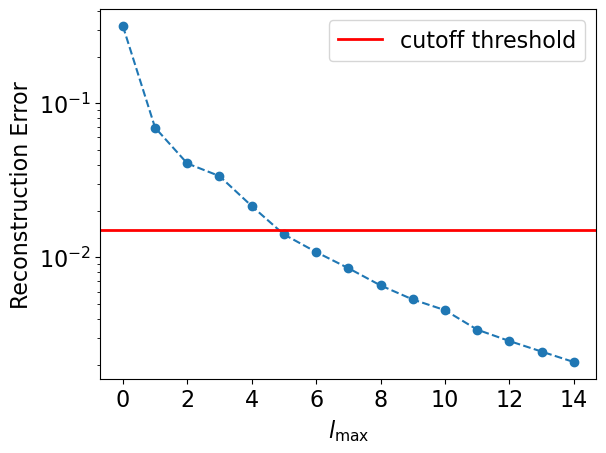

In [20]:
print('maximumm l index:', m.lmax)

errs = [] 
for l in range(0, m.lmax):
    err = m.compute_recon_quality(lmax=l+1)
    errs.append(err)    

plt.rcParams.update({'font.size': 16})
plt.plot(np.arange(0, m.lmax), errs, 'o--')
plt.axhline(y=0.015, color='r', linestyle='-', linewidth=2, label='cutoff threshold')
plt.xlabel(r'$l_{\max}$')
plt.ylabel('Reconstruction Error')
plt.xticks(ticks=np.arange(0, m.lmax, 2))
plt.legend() 
plt.yscale('log')
plt.savefig('Figures/recon_error.pdf')
plt.show() 



In [21]:
import pandas as pd
pd.DataFrame({'l_max': np.arange(0, m.lmax), 'reconstruction_error': errs}).to_csv('sim/recon_error_seal.csv', index=False)

### Compute HKS for a series of times (time ~ distance^2)

In [109]:
ts = [1, 4, 25, 100]
hks = m.compute_hks_for_new_times(ts, coeffs=False)

print(hks.shape) # fields associated with each vertex 
print(m.v.shape) 

(18001, 4)
(18001, 3)


In [137]:
plot(m.v, m.f, c=hks[:, 1])

Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(127.98705…

### Check correlation between markers

In [30]:
ts = [1, 4, 25, 100]

hks_coeffs = m.compute_hks_for_new_times(ts, coeffs=True)
coeffs = np.concatenate([coeffs_fm, hks_coeffs], axis=1)

NameError: name 'coeffs_fm' is not defined

/var/folders/5n/0rvnm9350db7gk5vdnj3tn6h0000gn/T/ipykernel_15426/1405150226.py:9: RuntimeWarning: invalid value encountered in scalar divide
  corr_matrix[i, j] = corr/np.sqrt(var_i * var_j)


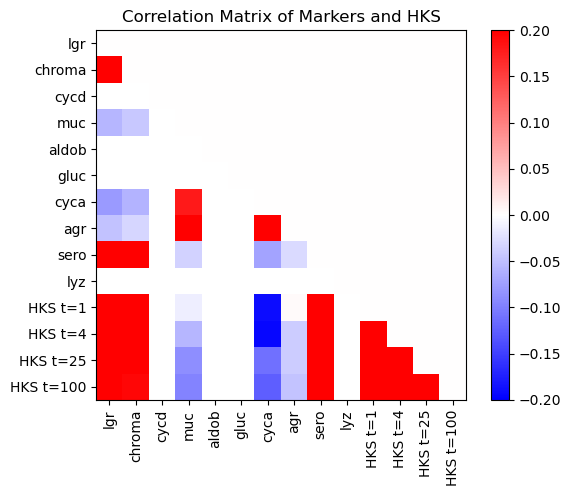

In [56]:
corr_matrix = np.zeros((coeffs.shape[1], coeffs.shape[1]))
for i in range(coeffs.shape[1]):
    for j in range(i+1, coeffs.shape[1]):

        corr = np.sum(coeffs[1:, i] * coeffs[1:, j]) / m.mass_matrix.diagonal().sum()

        var_i = np.sum(coeffs[1:, i]**2) / m.mass_matrix.diagonal().sum()
        var_j = np.sum(coeffs[1:, j]**2) / m.mass_matrix.diagonal().sum()
        corr_matrix[i, j] = corr/np.sqrt(var_i * var_j)

plt.imshow(corr_matrix.T, cmap='bwr', vmin=-0.2, vmax=0.2)
plt.colorbar()
plt.xticks(np.arange(len(correct_order) + len(ts)), correct_order + [f'HKS t={t}' for t in ts], rotation=90)
plt.yticks(np.arange(len(correct_order) + len(ts)), correct_order + [f'HKS t={t}' for t in ts])
plt.title('Correlation Matrix of Markers and HKS')
plt.show()

### Visualise the encoding using bag of features

In [7]:
# loads the vocab from file 
res = np.load('sim/vocab_new.npz', allow_pickle=True)
vocab = res['vocab']
scaler = res['scaler'].item() 
sigma = res['sigma']
ts = res['ts']

hks_fine = m.compute_hks_for_new_times(ts, coeffs=False)

/var/folders/5n/0rvnm9350db7gk5vdnj3tn6h0000gn/T/ipykernel_74249/1528645494.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('viridis')


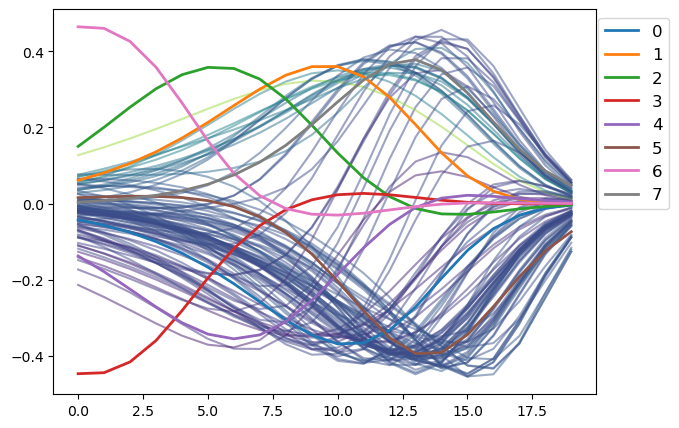

In [8]:
from matplotlib.colors import Normalize
from matplotlib import cm

random_indices = np.random.choice(hks_fine.shape[0], size=100, replace=False)

norm = Normalize(vmin=hks_fine[:, 0].min(), vmax=hks_fine[:, 0].max())
cmap = cm.get_cmap('viridis')

normalised_hks = (hks_fine/np.mean(hks_fine, axis=0, keepdims=True) - 1)
normalised_hks = scaler.transform(normalised_hks)



fig, ax = plt.subplots(figsize=(7, 5))
for ind in random_indices:
    ax.plot(normalised_hks[ind], color=cmap(norm(hks_fine[ind, 0])), alpha=0.5)

for i in range(len(vocab)):
    center = vocab[i]
    ax.plot(center, '-', linewidth=2, label=f'{i}')

plt.legend(loc='upper right', bbox_to_anchor=(1.15, 1), fontsize=12) 
# plt.colorbar(cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax, label='HKS at t=1')
plt.show()

In [9]:
dist = np.linalg.norm(normalised_hks[:, np.newaxis, :]-vocab[np.newaxis, :, :], axis=2)
print(np.min(dist[:, 0]))
encoding = np.exp(-dist**2 / (2 * sigma**2))

print(encoding.shape) 

0.05389185207356922
(18001, 8)


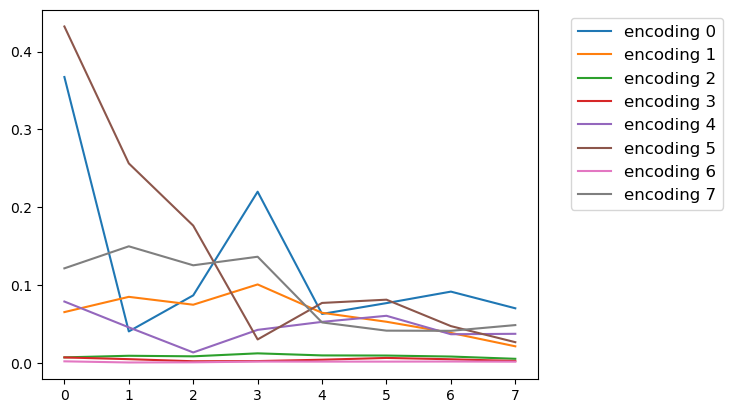

In [10]:
coeffs_hks = m.modes.T @ (m.mass_matrix @ encoding)
spectrums = m.compute_spectrum(coeffs_hks)

area = m.mass_matrix.diagonal().sum()
rescaled_spectrums = np.sqrt(spectrums/area) 

for i in range(rescaled_spectrums.shape[1]):
    plt.plot((rescaled_spectrums[:, i]), label=f'encoding {i}')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=12)
plt.show() 

In [11]:
for i in range(encoding.shape[1]):
    print(f'Feature {i}:')
    print(np.min(encoding[:, i]), np.max(encoding[:, i]))
    plot(m.v, m.f, c=encoding[:, i])

Feature 0:
1.4089912673847731e-06 0.9897248027048966


Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(-0.606637…

Feature 1:
1.3582887774544883e-06 0.8905386838432955


Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(-0.606637…

Feature 2:
2.2349007428914182e-06 0.25738188896833814


...

Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(-0.606637…

Feature 6:
1.5508097657980486e-05 0.12975288113635328


Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(-0.606637…

Feature 7:
2.3623164428702903e-06 0.9575386830089638


Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(-0.606637…

In [19]:
print(hks_fine.shape) 
index1 = np.argmax(encoding[:, 0]) 
index2 = np.argmax(encoding[:, 7])
index3 = np.argmax(encoding[:, 5])


p = plot(m.v, m.f, return_plot=True)
p.add_points(np.array([m.v[index1]]), shading={"point_color": "blue", "point_size": 5})
p.add_points(np.array([m.v[index2]]), shading={"point_color": "orange", "point_size": 5})
p.add_points(np.array([m.v[index3]]), shading={"point_color": "green", "point_size": 5})

(18001, 20)


Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(0.8606476…

3

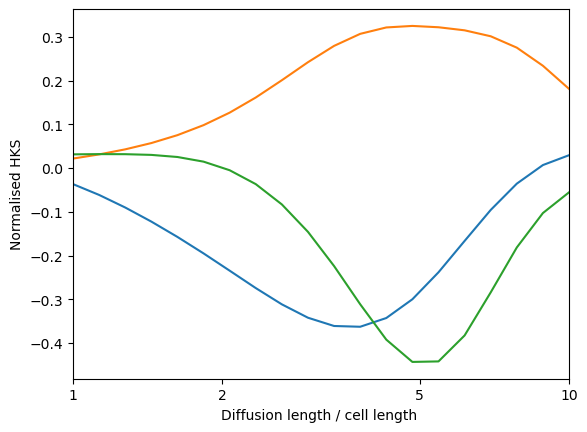

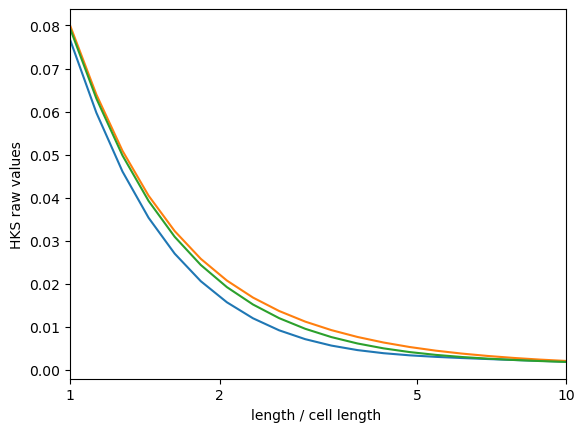

[7.003421   2.5269322  0.22635114] [-11.065087    2.9879518   2.8816042] [-6.895381   4.0683827  3.3074381]


In [21]:
x = np.sqrt(ts)
plt.plot(np.log(x), normalised_hks[index1], label=f'point {index1}')
plt.plot(np.log(x), normalised_hks[index2], label=f'point {index2}')
plt.plot(np.log(x), normalised_hks[index3], label=f'point {index3}')
plt.xticks(ticks=np.log([1, 2, 5, 10]), labels=[1, 2, 5, 10])
plt.xlabel('Diffusion length / cell length ')
plt.ylabel('Normalised HKS')
# plt.legend() 
plt.xlim([np.min(np.log(x)), np.max(np.log(x))])
plt.savefig('sim/normalised_hks.pdf')
plt.show()

plt.plot(np.log(x), hks_fine[index1], label=f'point {index1}')
plt.plot(np.log(x), hks_fine[index2], label=f'point {index2}')
plt.plot(np.log(x), hks_fine[index3], label=f'point {index3}')
plt.xticks(ticks=np.log([1, 2, 5, 10]), labels=[1, 2, 5, 10])
plt.xlabel('length / cell length ')
plt.ylabel('HKS raw values')
plt.xlim([np.min(np.log(x)), np.max(np.log(x))])
plt.show()

print(m.v[index1], m.v[index2], m.v[index3])

In [213]:
encoding_coeffs = m.modes.T @ (m.mass_matrix @ encoding)

vocab7_recons = [] 
for lmax in range(1, 7):
    print(f'Reconstruction with lmax={lmax-1}')
    hks_recons = m.reconstruct_from_coeffs(encoding_coeffs, lmax=lmax)
    plot(m.v, m.f, c=hks_recons[:, -1])
    vocab7_recons.append(hks_recons[:, -1])
    print(np.min(hks_recons[:, -1]), np.max(hks_recons[:, -1]))

Reconstruction with lmax=0


Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(127.98705…

0.12266415 0.12266959
Reconstruction with lmax=1


Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(127.98705…

-0.03688887 0.25059074
Reconstruction with lmax=2


...

-0.13901609 0.60722643
Reconstruction with lmax=4


Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(127.98705…

-0.10503311 0.7736318
Reconstruction with lmax=5


Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(127.98705…

-0.08152691 0.7850822


### Visualise the reconstructed fate markers

In [ ]:

coeffs_fm = m.modes.T @ ( m.mass_matrix @ m.fields)


recon_field = m.modes[:, :int(m.lmax**2)] @ coeffs_fm[:int(m.lmax**2)]

for (i, name) in enumerate(m.field_names):
    if i in [0, 1]:
        print(name)
        print(np.min(m.fields[:, i]), np.max(m.fields[:, i]))
        print(np.min(recon_field[:, i]), np.max(recon_field[:, i]))
        plot(m.v, m.f, c=m.fields[:, i]) # note that this doesn't work if we load mesh results directly 
        plot(m.v, m.f, c=recon_field[:, i])

2.C04.percentile99_class
0.0 1735.8
-173.35007 1573.2231


Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(127.98705…

Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(127.98705…

0.C02.percentile99_class
0.0 6640.75
-769.22314 6098.776


Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(127.98705…

Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(127.98705…

In [123]:
from vtk.util.numpy_support import numpy_to_vtk

def save_vtp(path, file_path, field_names, fields):
    """
    field_names: list of strings
    fields: np.array of shape (n_vertices, n_fields)
    """

    m._load_vtp(path) 
    polydata = vtk.vtkPolyData()

    # Set vertices
    points = vtk.vtkPoints()
    points.SetData(numpy_to_vtk(m.v))
    polydata.SetPoints(points)

    # Set faces
    cells = vtk.vtkCellArray()
    for face in m.f:
        cells.InsertNextCell(3)
        for vid in face:
            cells.InsertCellPoint(int(vid))
    polydata.SetPolys(cells)

    # Add scalar fields
    for i, name in enumerate(field_names):
        array = numpy_to_vtk(fields[:, i].copy())
        array.SetName(name)
        polydata.GetPointData().AddArray(array)

    # Write
    writer = vtk.vtkXMLPolyDataWriter()
    writer.SetFileName(file_path)
    writer.SetInputData(polydata)
    writer.Write()

file_path = 'sim/test.vtp'
vocab_names = [f'vocab-{i}' for i in range(8)]
field_names = m.field_names + ['hks-1', 'hks-2', 'hks-5', 'hks-10'] + vocab_names
fields = np.hstack([m.fields, hks, encoding])

print(fields.shape, m.fields.shape, hks.shape, encoding.shape) 

save_vtp(path, file_path, field_names, fields) 

(18001, 19) (18001, 7) (18001, 4) (18001, 8)


In [124]:
m_copy = FateMarkers()
m_copy._load_vtp(file_path)

print(m_copy.fields.shape)

plot(m_copy.v, m_copy.f, m_copy.fields[:, -1])
plot(m_copy.v, m_copy.f, fields[:, -1])

(18001, 19)


Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(127.98705…

Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(127.98705…

In [218]:
vocab7_recons = np.array(vocab7_recons).T
print(vocab7_recons.shape)


file_path = 'sim/vocab7_recon.vtp'
field_names = [f'vocab7 recon with lmax={i}' for i in range(1, 7)]

save_vtp(path, file_path, field_names, vocab7_recons) 

(18001, 6)


In [219]:
m_copy = FateMarkers()
m_copy._load_vtp(file_path)

print(m_copy.fields.shape)

plot(m_copy.v, m_copy.f, m_copy.fields[:, -1])
plot(m_copy.v, m_copy.f, vocab7_recons[:, -1])

(18001, 6)


Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(127.98705…

Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(127.98705…

In [12]:

for lmax in range(0, 15): 
    print(lmax) 
    v_recon = m.reconstruct_from_coeffs(m.coeffs_v, lmax=lmax+1)
    plot(v_recon, m.f) 
    igl.write_triangle_mesh(f'sim/recon_lmax_{lmax}.stl', v_recon, m.f)

0


Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(-0.354490…

1


Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(2.4283533…

2


...

Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(0.8417110…

13


Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(0.8470182…

14


Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(0.8830151…